=== 1. REZUMAT SINTETIC: TOTAL ECONOMIE ===
Salariu Mediu Net Iunie 2026: 5734 RON
Față de Mai 2026: +50 RON (+0.88%)
Față de Iunie 2025: +195 RON (+3.52%)

=== 2. TOP 5 DOMENII CU CELE MAI MARI CREȘTERI SALARIALE ===
- Fabricarea produselor din tutun: +26.27% (8861 RON -> 11189 RON)
- Publicitate, activităţi de studiere a pieţei și relatii publice: +17.44% (6399 RON -> 7515 RON)
- Fabricarea calculatoarelor şi a produselor electronice şi optice: +13.89% (6597 RON -> 7513 RON)
- Tipărire şi reproducerea pe suporţi a înregistrărilor: +13.76% (4410 RON -> 5017 RON)
- Activităţi de servicii privind forţa de muncă: +13.67% (4535 RON -> 5155 RON)


=== 3. EVOLUȚIA SALARIULUI NET ÎN IT ===
      Luna  Salariu_IT
 Iun. 2025     11143.0
 Iul. 2025     11032.0
 Aug. 2025     10638.0
Sept. 2025     11215.0
 Oct. 2025     10924.0
 Nov. 2025     11824.0
 Dec. 2025     11830.0
 Ian. 2026     11077.0
Febr. 2026     11237.0
Mart. 2026     13352.0
 Apr. 2026     12292.0
  Mai 2026     11333.0
 Iun. 20

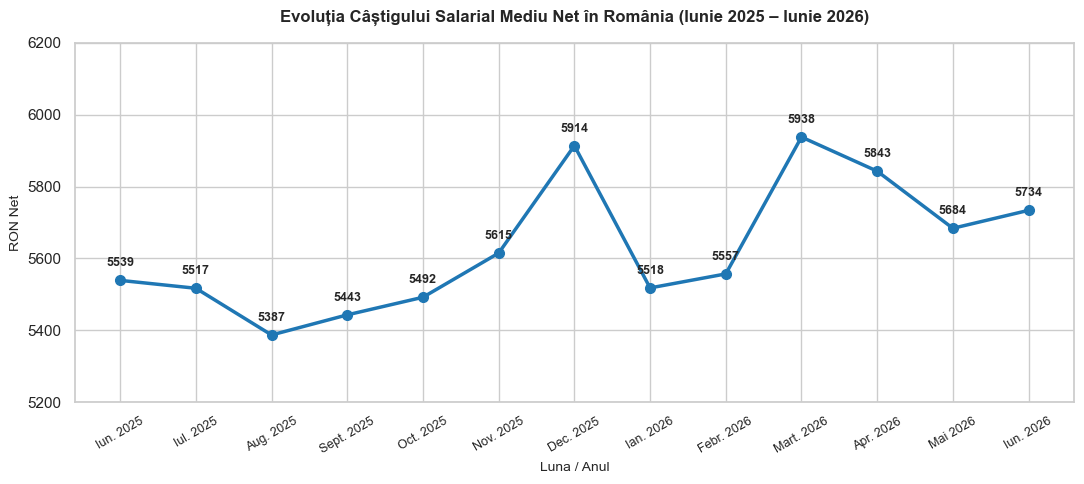

C:\Users\AnaTiru\AppData\Local\Temp\ipykernel_19660\357235376.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5, x='Crestere_YoY_%', y='Domeniu', ax=axes[0], palette='viridis')


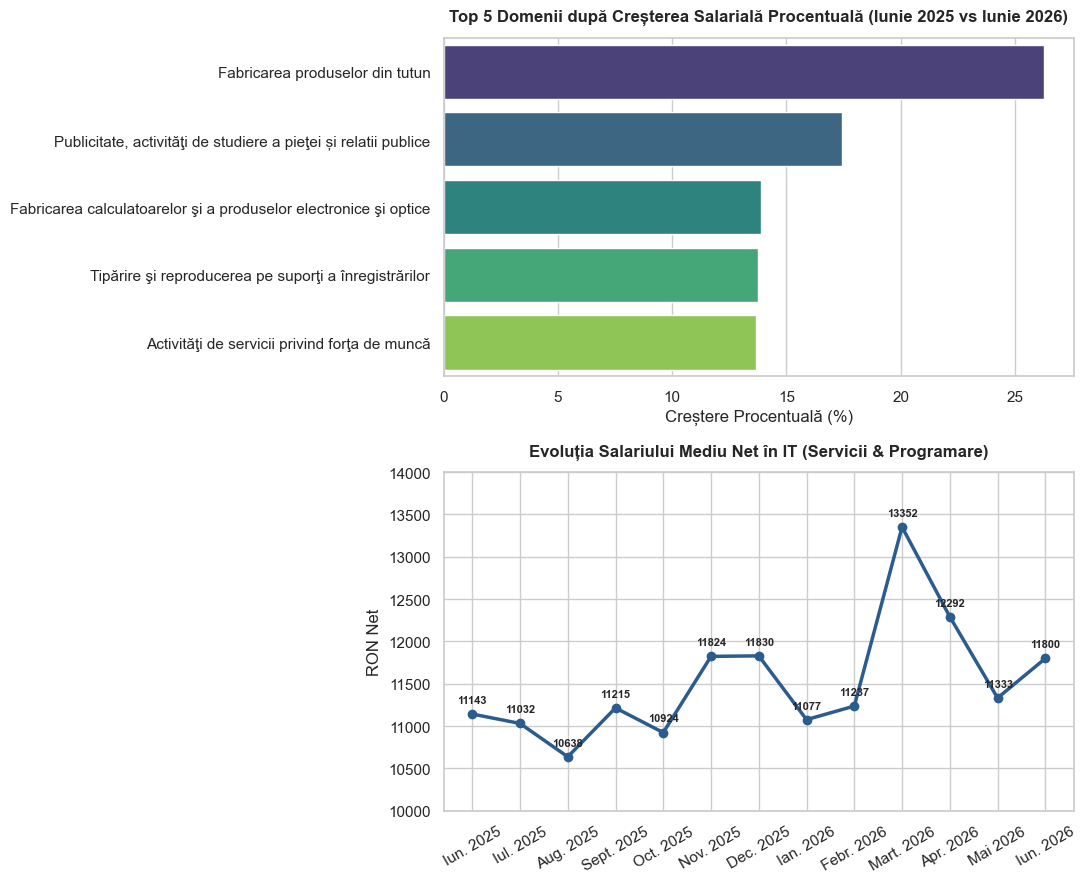

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. ÎNCĂRCAREA ȘI PREGĂTIREA DATELOR (INS)
# ==========================================
file_path = 'salariul_mediu_ins.xlsx'
df = pd.read_excel(file_path, sheet_name=0)

# Lista lunilor analizate (Iunie 2025 - Iunie 2026)
luni = [
    'Iun. 2025', 'Iul. 2025', 'Aug. 2025', 'Sept. 2025', 'Oct. 2025', 
    'Nov. 2025', 'Dec. 2025', 'Ian. 2026', 'Febr. 2026', 'Mart. 2026', 
    'Apr. 2026', 'Mai 2026', 'Iun. 2026'
]

# Curățăm și structurăm datele pe domenii economice
df_sectors = df.iloc[3:, :15].copy()
df_sectors.columns = ['Domeniu', 'Cod_CAEN'] + luni

# Conversie coloane la valori numerice
for col in luni:
    df_sectors[col] = pd.to_numeric(df_sectors[col], errors='coerce')


# ==========================================
# 2. ANALIZA 1: TOTAL ECONOMIE (MEDIA NAȚIONALĂ)
# ==========================================
total_row = df[df.iloc[:, 0].astype(str).str.contains('TOTAL ECONOMIE', na=False)]
valori_total = total_row.iloc[0, 2:15].values.astype(float)
df_total = pd.DataFrame({'Luna': luni, 'Salariu_Net': valori_total})

# Calculăm variațiile cheie
mai_2026 = df_total.loc[df_total['Luna'] == 'Mai 2026', 'Salariu_Net'].values[0]
iun_2026 = df_total.loc[df_total['Luna'] == 'Iun. 2026', 'Salariu_Net'].values[0]
iun_2025 = df_total.loc[df_total['Luna'] == 'Iun. 2025', 'Salariu_Net'].values[0]

diff_mai = iun_2026 - mai_2026
pct_mai = (diff_mai / mai_2026) * 100

diff_iun25 = iun_2026 - iun_2025
pct_iun25 = (diff_iun25 / iun_2025) * 100

print("=== 1. REZUMAT SINTETIC: TOTAL ECONOMIE ===")
print(f"Salariu Mediu Net Iunie 2026: {iun_2026:.0f} RON")
print(f"Față de Mai 2026: {diff_mai:+.0f} RON ({pct_mai:+.2f}%)")
print(f"Față de Iunie 2025: {diff_iun25:+.0f} RON ({pct_iun25:+.2f}%)\n")


# ==========================================
# 3. ANALIZA 2: TOP 5 CREȘTERI SALARIALE (YoY %)
# ==========================================
# Eliminăm rândurile de sumare/totaluri generale
df_clean = df_sectors[~df_sectors['Domeniu'].str.contains('total', case=False, na=False)].dropna(subset=['Iun. 2025', 'Iun. 2026'])

# Calculăm creșterea procentuală Iunie 2025 vs Iunie 2026
df_clean['Crestere_YoY_%'] = ((df_clean['Iun. 2026'] - df_clean['Iun. 2025']) / df_clean['Iun. 2025']) * 100
top_5 = df_clean.sort_values(by='Crestere_YoY_%', ascending=False).head(5)

print("=== 2. TOP 5 DOMENII CU CELE MAI MARI CREȘTERI SALARIALE ===")
for idx, row in top_5.iterrows():
    print(f"- {row['Domeniu']}: +{row['Crestere_YoY_%']:.2f}% ({row['Iun. 2025']:.0f} RON -> {row['Iun. 2026']:.0f} RON)")
print("\n")


# ==========================================
# 4. ANALIZA 3: SECTORUL IT (PROGRAMARE & CONSULTANȚĂ)
# ==========================================
it_row = df_sectors[df_sectors['Domeniu'].str.contains('programare', case=False, na=False)]
it_data = pd.DataFrame({'Luna': luni, 'Salariu_IT': it_row[luni].values[0]})

print("=== 3. EVOLUȚIA SALARIULUI NET ÎN IT ===")
print(it_data.to_string(index=False))
print("\n")


# ==========================================
# 5. GENERARE VIZUALIZĂRI (GRAFICE)
# ==========================================
sns.set_theme(style="whitegrid")

# GRAFIC 1: Evoluția Salariului Mediu Net pe Economie
plt.figure(figsize=(11, 5))
plt.plot(df_total['Luna'], df_total['Salariu_Net'], marker='o', linewidth=2.5, color='#1f77b4', markersize=7)

for i, txt in enumerate(df_total['Salariu_Net']):
    plt.annotate(f"{int(txt)}", (df_total['Luna'][i], df_total['Salariu_Net'][i]),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')

plt.title('Evoluția Câștigului Salarial Mediu Net în România (Iunie 2025 – Iunie 2026)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Luna / Anul', fontsize=10)
plt.ylabel('RON Net', fontsize=10)
plt.xticks(rotation=30, fontsize=9)
plt.ylim(5200, 6200)
plt.tight_layout()
plt.show()

# GRAFIC 2 (COMBINAT): Top 5 Creșteri & Evoluția din IT
fig, axes = plt.subplots(2, 1, figsize=(11, 9))

# Subplot A: Top 5 Domenii după Creșterea Procentuală
sns.barplot(data=top_5, x='Crestere_YoY_%', y='Domeniu', ax=axes[0], palette='viridis')
axes[0].set_title('Top 5 Domenii după Creșterea Salarială Procentuală (Iunie 2025 vs Iunie 2026)', fontweight='bold', pad=12)
axes[0].set_xlabel('Creștere Procentuală (%)')
axes[0].set_ylabel('')

# Subplot B: Linia de evoluție pentru IT
axes[1].plot(it_data['Luna'], it_data['Salariu_IT'], marker='o', linewidth=2.5, color='#2b5c8f', markersize=6)
for i, txt in enumerate(it_data['Salariu_IT']):
    axes[1].annotate(f"{int(txt)}", (it_data['Luna'][i], it_data['Salariu_IT'][i]),
                     textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8, fontweight='bold')

axes[1].set_title('Evoluția Salariului Mediu Net în IT (Servicii & Programare)', fontweight='bold', pad=12)
axes[1].set_ylabel('RON Net')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(10000, 14000)

plt.tight_layout()
plt.show()
    